In [1]:
import os
import dill as pk
import h5py
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import socolors

import astropy.constants as consts
from astropy import units as u
from astropy.time import Time

from latcom.utils.optical_loading import pwv_interp


# Display inline plots
%matplotlib inline

%load_ext autoreload
%autoreload 2

# Quick Look Plotting

In [3]:
with open("../abscals/results_06262026.pk", "rb") as f:
    result_dict = pk.load(f)
with open("../backups/results_12032025.pk", "rb") as f:
    old_result_dict = pk.load(f)
with open("../data/r3v8_sim.pk", "rb") as f:
    sim = pk.load(f)


c_base = (220 / 255, 50 / 255, 32 / 255)
c_goal = (0 / 255, 90 / 255, 181 / 255)

In [4]:
labels = []
cals = []
obs = []
pwvs = []
data_omegas = []
fwhms = []
sources = []
times = []

pwv = pwv_interp()

freqs = ["030", "040", "090", "150", "220", "280"]
ufms = sorted(result_dict.keys())

for (
    freq
) in freqs:  # This is slighly inefficient but the ezest way to sort by freq then ufm
    for ufm in ufms:
        for key in result_dict.keys():
            if ufm not in key:
                continue
            for sub_key in result_dict[key].keys():
                if freq not in sub_key:
                    continue
                cur_cals = np.array(result_dict[key][sub_key]["cal"])
                cur_obs = np.array(result_dict[key][sub_key]["obs"])
                cur_omegas = np.array(result_dict[key][sub_key]["omega_data"])
                cur_sources = np.array(result_dict[key][sub_key]["source"])
                cur_fwhms = np.array(result_dict[key][sub_key]["fwhm"])
                cur_times = np.array(result_dict[key][sub_key]["time"])

                label = str(freq) + "_" + str(ufm)
                for j in range(len(cur_cals)):
                    cur_pwv = pwv(cur_obs[j].split("_")[2])
                    cals.append(cur_cals[j])
                    labels.append(label)
                    obs.append(cur_obs[j])
                    pwvs.append(cur_pwv)
                    data_omegas.append(cur_omegas[j])
                    sources.append(cur_sources[j].capitalize())
                    fwhms.append(cur_fwhms[j])
                    times.append(float(cur_times[j]))

labels = np.array(labels)
cals = np.array(cals)
obs = np.array(obs)
pwvs = np.array(pwvs)
data_omegas = np.array(data_omegas)
sources = np.array(sources)
fwhms = np.array(fwhms)
times = np.array(times)


df = pd.DataFrame(
    {
        "labels": labels,
        "cals": cals,
        "obs": obs,
        "pwvs": pwvs,
        "omegas": data_omegas,
        "sources": sources,
        "fwhms": fwhms,
        "times": times,
    }
)

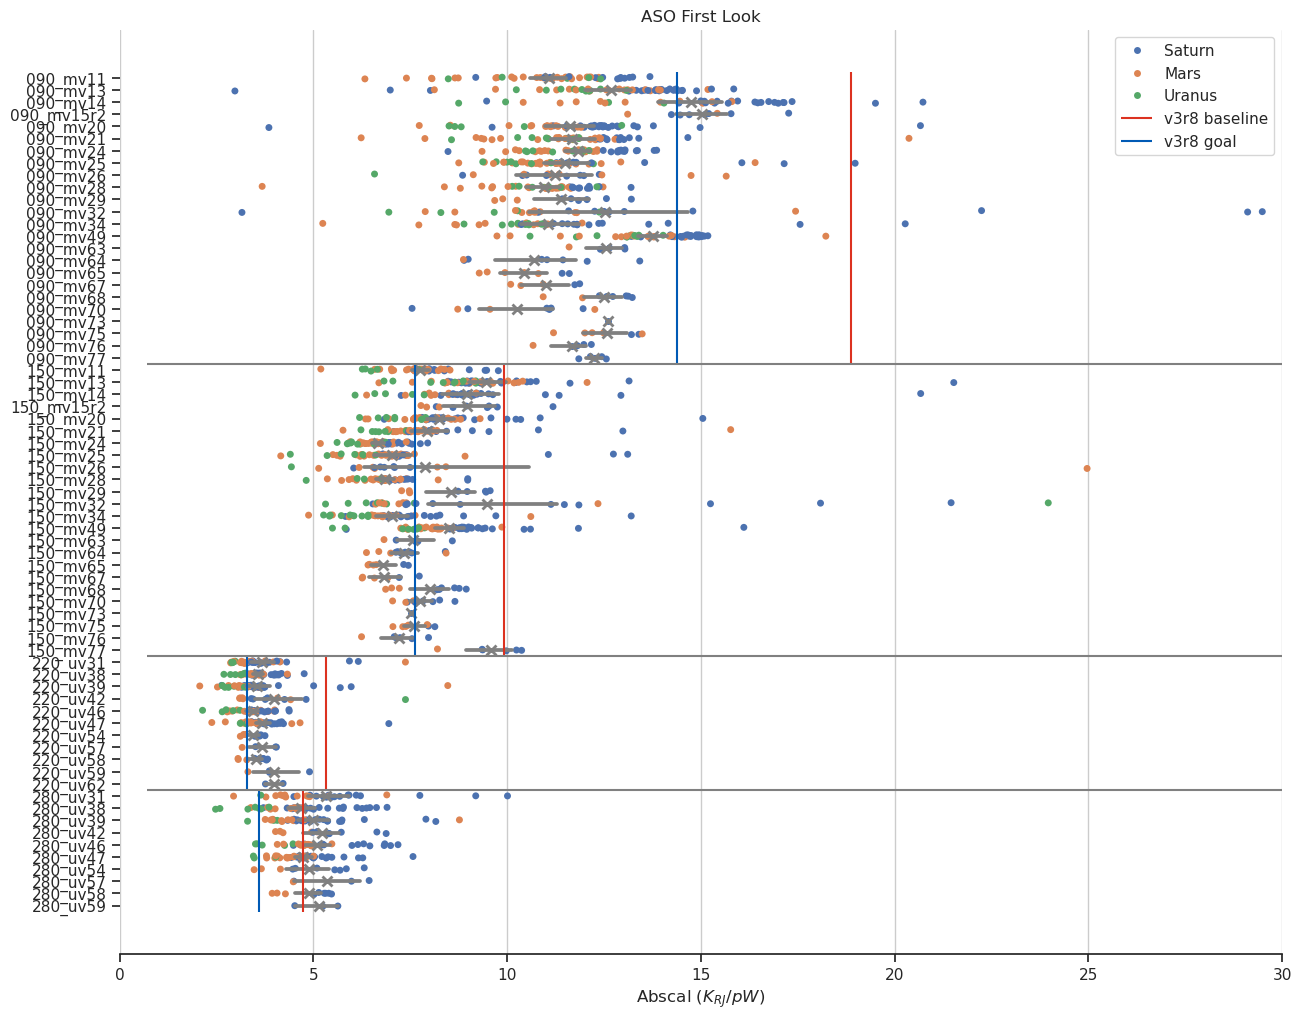

In [5]:
sns.set_theme(style="ticks")
t_cut = Time("2024-09-03T00:00:00", format="isot", scale="utc")


# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(15, 12))

# Add in points to show each observation
sns.stripplot(
    df.where((df.pwvs < 3) & (df.cals < 30) & (df.times > t_cut.unix)),
    x="cals",
    y="labels",
    hue="sources",
    zorder=1,
)  # note somewhat nasty cut on cals since neptune keeps slipping into our saturn obs
sns.pointplot(
    data=df.where((df.pwvs < 3) & (df.cals < 30) & (df.times > t_cut.unix)),
    x="cals",
    y="labels",
    linestyle="none",
    marker="x",
    color="0.5",
    zorder=2,
)

ymax, ymin = ax.get_ylim()
xmax, xmin = ax.get_xlim()

pos_090 = len([label for label in set(df[(df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)].labels.to_numpy()) if "090" in label]) - 0.5
pos_150 = pos_090 + len([label for label in set(df[(df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)].labels.to_numpy()) if "150" in label])
pos_220 = pos_150 + len([label for label in set(df[(df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)].labels.to_numpy()) if "220" in label])
pos_280 = pos_220 + len([label for label in set(df[(df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)].labels.to_numpy()) if "280" in label])

plt.vlines(1.0 / (1e12 * (sim["MF"]["baseline"]["MF_1"]["dpdt_rj"])), ymin=ymin, ymax=pos_090, label="v3r8 baseline", color=c_base,)
plt.vlines(1.0 / (1e12 * (sim["MF"]["goal"]["MF_1"]["dpdt_rj"])), ymin=ymin, ymax=pos_090, label="v3r8 goal", color=c_goal,)

plt.vlines(1.0 / (1e12 * (sim["MF"]["baseline"]["MF_2"]["dpdt_rj"])), ymin=pos_090, ymax=pos_150, label=None, color=c_base,)
plt.vlines(1.0 / (1e12 * (sim["MF"]["goal"]["MF_2"]["dpdt_rj"])), ymin=pos_090, ymax=pos_150, label=None, color=c_goal,)

plt.vlines(1.0 / (1e12 * (sim["UHF"]["baseline"]["UHF_1"]["dpdt_rj"])), ymin=pos_150, ymax=pos_220, label=None, color=c_base,)
plt.vlines(1.0 / (1e12 * (sim["UHF"]["goal"]["UHF_1"]["dpdt_rj"])), ymin=pos_150, ymax=pos_220, label=None, color=c_goal,)

plt.vlines(1.0 / (1e12 * (sim["UHF"]["baseline"]["UHF_2"]["dpdt_rj"])), ymin=pos_220, ymax=ymax, label=None, color=c_base,)
plt.vlines(1.0 / (1e12 * (sim["UHF"]["goal"]["UHF_2"]["dpdt_rj"])), ymin=pos_220, ymax=ymax, label=None, color=c_goal,)

plt.hlines([pos_090, pos_150, pos_220], xmin=xmin, xmax=xmax, color="0.5")

plt.xlim(0, 30)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(xlabel="Abscal ($K_{RJ}/pW$)", ylabel="", title="ASO First Look")
sns.despine(trim=True, left=True)

plt.legend()
plt.savefig("../plts/abscals/abscals_062526.png", dpi=300)
plt.savefig("../plts/abscals/abscals_062526.pdf", dpi=300)

# APJ Figure

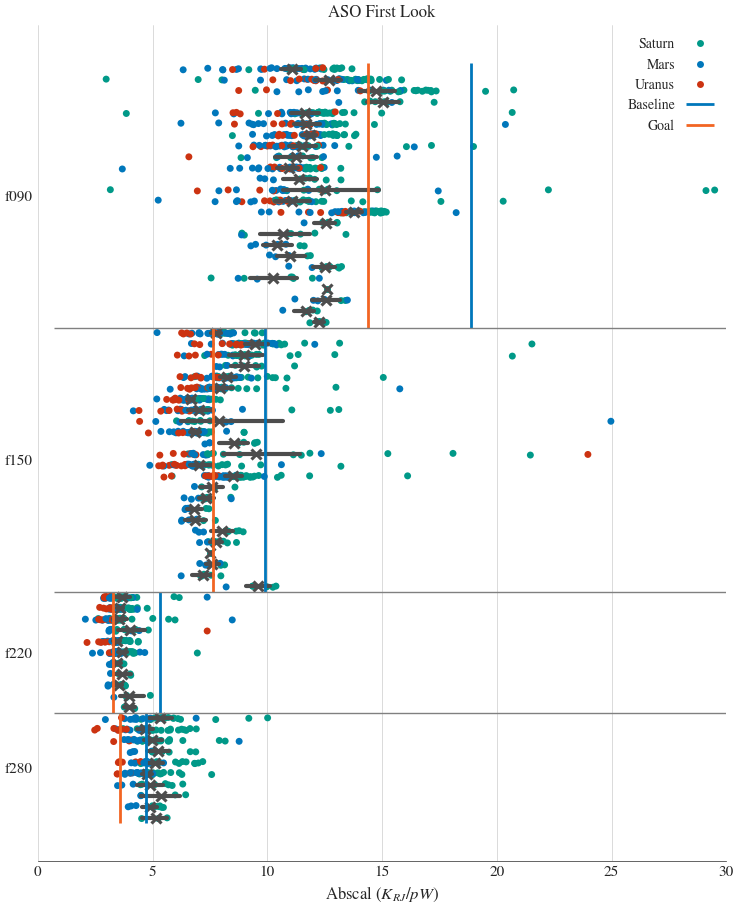

In [6]:
plt.style.use("apj-fullwidth")

c_base = "C0"
c_goal = "C3"

custom_mapping = {
    "Mars": "C0", # Hex code
    "Saturn": "C2", # Named color
    "Uranus": "C4" # Shorthand code
}

t_cut = Time("2024-09-03T00:00:00", format="isot", scale="utc")


# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7.3, 9))

# Add in points to show each observation
sns.stripplot(
    df.where((df.pwvs < 3) & (df.cals < 30) & (df.times > t_cut.unix)),
    x="cals",
    y="labels",
    hue="sources",
    palette=custom_mapping,
    zorder=1,
)  # note somewhat nasty cut on cals since neptune keeps slipping into our saturn obs
sns.pointplot(
    data=df.where((df.pwvs < 3) & (df.cals < 30) & (df.times > t_cut.unix)),
    x="cals",
    y="labels",
    linestyle="none",
    marker="x",
    color="0.3",
    linewidth=3,
    zorder=2,
)

ymax, ymin = ax.get_ylim()
xmax, xmin = ax.get_xlim()

pos_090 = (len([label for label in set(df[(df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)].labels.to_numpy()) if "090" in label]) - 0.5)
pos_150 = pos_090 + len([label for label in set(df[(df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)].labels.to_numpy()) if "150" in label])
pos_220 = pos_150 + len([label for label in set(df[(df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)].labels.to_numpy()) if "220" in label])
pos_280 = pos_220 + len([label for label in set(df[(df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)].labels.to_numpy()) if "280" in label])

plt.vlines(1.0 / (1e12 * (sim["MF"]["baseline"]["MF_1"]["dpdt_rj"])), ymin=ymin, ymax=pos_090, label="Baseline", color=c_base,)
plt.vlines(1.0 / (1e12 * (sim["MF"]["goal"]["MF_1"]["dpdt_rj"])), ymin=ymin, ymax=pos_090, label="Goal", color=c_goal,)

plt.vlines(1.0 / (1e12 * (sim["MF"]["baseline"]["MF_2"]["dpdt_rj"])), ymin=pos_090, ymax=pos_150, label=None, color=c_base,)
plt.vlines(1.0 / (1e12 * (sim["MF"]["goal"]["MF_2"]["dpdt_rj"])), ymin=pos_090, ymax=pos_150, label=None, color=c_goal,)

plt.vlines(1.0 / (1e12 * (sim["UHF"]["baseline"]["UHF_1"]["dpdt_rj"])), ymin=pos_150, ymax=pos_220, label=None, color=c_base,)
plt.vlines(1.0 / (1e12 * (sim["UHF"]["goal"]["UHF_1"]["dpdt_rj"])), ymin=pos_150, ymax=pos_220, label=None, color=c_goal,)

plt.vlines(1.0 / (1e12 * (sim["UHF"]["baseline"]["UHF_2"]["dpdt_rj"])), ymin=pos_220, ymax=ymax, label=None, color=c_base,)
plt.vlines(1.0 / (1e12 * (sim["UHF"]["goal"]["UHF_2"]["dpdt_rj"])), ymin=pos_220, ymax=ymax, label=None, color=c_goal,)

plt.hlines([pos_090, pos_150, pos_220], xmin=xmin, xmax=xmax, color="0.5", linewidth=1)

plt.xlim(0, 30)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(xlabel="Abscal ($K_{RJ}/pW$)", ylabel="", title="ASO First Look")
tick_locations = [np.mean([ymin, pos_090]), np.mean([pos_090, pos_150]), np.mean([pos_150, pos_220]), np.mean([pos_220, ymax])]
tick_labels = ['f090', 'f150', 'f220', 'f280']
ax.set_yticks(tick_locations, labels=tick_labels)
ax.tick_params(axis='x', which='both', bottom=False, top=False)
ax.tick_params(axis='y', which='both', left=False, right=False)
sns.despine(trim=True, left=True)

plt.legend(markerfirst=False)
plt.savefig("../plts/abscals/abscals_062526_APJ.png", dpi=300)
plt.savefig("../plts/abscals/abscals_062526_APJ.pdf")

In [6]:
labels = []
cals = []
obs = []
pwvs = []
data_omegas = []
fwhms = []
sources = []
times = []

pwv = pwv_interp()

freqs = ["090", "150", "220", "280"]
ufms = sorted(result_dict.keys())

for (
    freq
) in freqs:  # This is slighly inefficient but the ezest way to sort by freq then ufm
    for ufm in ufms:
        for key in old_result_dict.keys():
            if ufm not in key:
                continue
            for sub_key in old_result_dict[key].keys():
                if freq not in sub_key:
                    continue
                cur_cals = np.array(old_result_dict[key][sub_key]["cal"])
                cur_obs = np.array(old_result_dict[key][sub_key]["obs"])
                cur_omegas = np.array(old_result_dict[key][sub_key]["omega_data"])
                cur_sources = np.array(old_result_dict[key][sub_key]["source"])
                cur_fwhms = np.array(old_result_dict[key][sub_key]["fwhm"])
                cur_times = np.array(old_result_dict[key][sub_key]["time"])

                label = str(freq) + "_" + str(ufm)
                for j in range(len(cur_cals)):
                    cur_pwv = pwv(cur_obs[j].split("_")[2])
                    cals.append(cur_cals[j])
                    labels.append(label)
                    obs.append(cur_obs[j])
                    pwvs.append(cur_pwv)
                    data_omegas.append(cur_omegas[j])
                    sources.append(cur_sources[j])
                    fwhms.append(cur_fwhms[j])
                    times.append(float(cur_times[j]))

labels = np.array(labels)
cals = np.array(cals)
obs = np.array(obs)
pwvs = np.array(pwvs)
data_omegas = np.array(data_omegas)
sources = np.array(sources)
fwhms = np.array(fwhms)
times = np.array(times)


old_df = pd.DataFrame(
    {
        "labels": labels,
        "cals": cals,
        "obs": obs,
        "pwvs": pwvs,
        "omegas": data_omegas,
        "sources": sources,
        "fwhms": fwhms,
        "times": times,
    }
)

In [7]:
my_labels = np.unique(labels)
mars_cals = np.zeros(len(my_labels))
sat_cals = np.zeros(len(my_labels))
mars_std = np.zeros(len(my_labels))
sat_std = np.zeros(len(my_labels))

for i, label in enumerate(my_labels):
    mars_cals[i] = np.nanmean(df.where(df["labels"].str.contains(label)).where(df["sources"] == "mars").cals)
    sat_cals[i] = np.nanmean(df.where(df["labels"].str.contains(label)).where(df["sources"] == "saturn").cals)
    mars_std[i] = np.nanstd(df.where(df["labels"].str.contains(label)).where(df["sources"] == "mars").cals)
    sat_std[i] = np.nanstd(df.where(df["labels"].str.contains(label)).where(df["sources"] == "saturn").cals    )
    # print(np.nanmean(df.where(df["labels"].str.contains(label)).where(df["sources"]=="mars").cals), np.nanmean(df.where(df["labels"].str.contains(label)).where(df["sources"]=="saturn").cals))

/tmp/ipykernel_345176/939895445.py:8: RuntimeWarning: Mean of empty slice
  mars_cals[i] = np.nanmean(df.where(df["labels"].str.contains(label)).where(df["sources"]=="mars").cals)
/tmp/ipykernel_345176/939895445.py:9: RuntimeWarning: Mean of empty slice
  sat_cals[i] = np.nanmean(df.where(df["labels"].str.contains(label)).where(df["sources"]=="saturn").cals)
/so/home/jorlo/venvs/sotodlib/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/so/home/jorlo/venvs/sotodlib/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_345176/939895445.py:8: RuntimeWarning: Mean of empty slice
  mars_cals[i] = np.nanmean(df.where(df["labels"].str.contains(label)).where(df["sources"]=="mars").cals)
/tmp/ipykernel_345176/939895445.py:9: R

In [8]:
unique_obs = set(obs)
times = np.empty(len(unique_obs))
for i, ob in enumerate(unique_obs):
    times[i] = ob.split("_")[-1]

<ErrorbarContainer object of 3 artists>

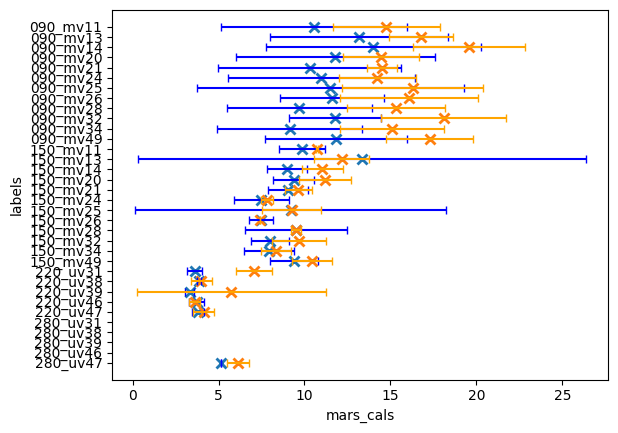

In [9]:
my_df = pd.DataFrame(
    {
        "labels": my_labels,
        "mars_cals": mars_cals,
        "sat_cals": sat_cals,
        "mars_std": mars_std,
        "sat_std": sat_std,
    }
)

fig, ax = plt.subplots()
sns.pointplot(
    data=my_df,
    y="labels",
    x="mars_cals",
    linestyle="none",
    marker="x",
    ax=ax,
)
sns.pointplot(
    data=my_df,
    y="labels",
    x="sat_cals",
    linestyle="none",
    marker="x",
    ax=ax,
)

ax.errorbar(
    x=my_df["mars_cals"],
    y=my_df["labels"],
    xerr=my_df["mars_std"],  # Your pre-calculated errors
    fmt="none",  # No line connecting points
    color="blue",
    capsize=3,
)

ax.errorbar(
    x=my_df["sat_cals"],
    y=my_df["labels"],
    xerr=my_df["sat_std"],  # Your pre-calculated errors
    fmt="none",  # No line connecting points
    color="orange",
    capsize=3,
)

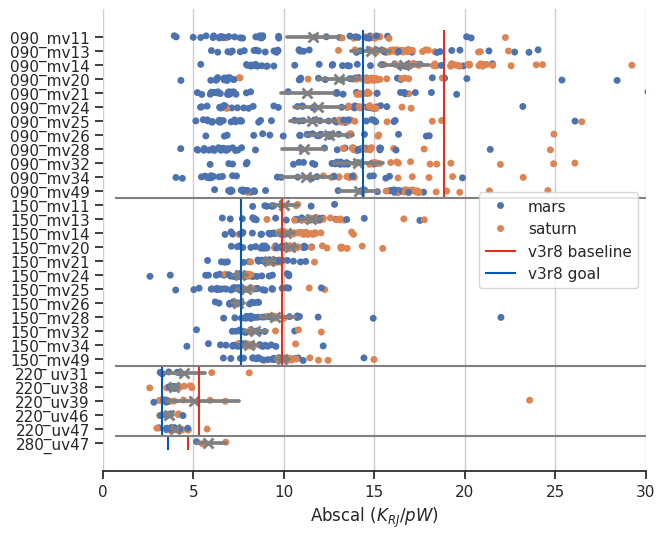

In [10]:
sns.set_theme(style="ticks")
t_cut = Time("2024-09-03T00:00:00", format="isot", scale="utc")


# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7, 6))
# ax.set_xscale("log")

# Load the example planets dataset
# planets = sns.load_dataset("planets")

# Plot the orbital period with horizontal boxes
# sns.boxplot(
#    planets, x="distance", y="method", hue="method",
#    whis=[0, 100], width=.6, palette="vlag"
# )

# Add in points to show each observation
sns.stripplot(
    df.where((df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)),
    x="cals",
    y="labels",
    hue="sources",
    zorder=1,
)  # note somewhat nasty cut on cals since neptune keeps slipping into our saturn obs
sns.pointplot(
    data=df.where((df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)),
    x="cals",
    y="labels",
    linestyle="none",
    marker="x",
    color="0.5",
    zorder=2,
)

ymax, ymin = ax.get_ylim()
xmax, xmin = ax.get_xlim()

pos_090 = (len([label for label in set(df[(df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)].labels.to_numpy()) if "090" in label]) - 0.5)
pos_150 = pos_090 + len([label for label in set(df[(df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)].labels.to_numpy()) if "150" in label])
pos_220 = pos_150 + len([label for label in set(df[(df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)].labels.to_numpy()) if "220" in label])
pos_280 = pos_220 + len([label for label in set(df[(df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)].labels.to_numpy()) if "280" in label])

plt.vlines(1.0 / (1e12 * (sim["MF"]["baseline"]["MF_1"]["dpdt_rj"])), ymin=ymin, ymax=pos_090, label="v3r8 baseline", color=c_base,)
plt.vlines(1.0 / (1e12 * (sim["MF"]["goal"]["MF_1"]["dpdt_rj"])), ymin=ymin, ymax=pos_090, label="v3r8 goal", color=c_goal,)

plt.vlines(1.0 / (1e12 * (sim["MF"]["baseline"]["MF_2"]["dpdt_rj"])), ymin=pos_090, ymax=pos_150, label=None, color=c_base,)
plt.vlines(1.0 / (1e12 * (sim["MF"]["goal"]["MF_2"]["dpdt_rj"])), ymin=pos_090, ymax=pos_150, label=None, color=c_goal,)

plt.vlines(1.0 / (1e12 * (sim["UHF"]["baseline"]["UHF_1"]["dpdt_rj"])), ymin=pos_150, ymax=pos_220, label=None, color=c_base,)
plt.vlines(1.0 / (1e12 * (sim["UHF"]["goal"]["UHF_1"]["dpdt_rj"])), ymin=pos_150, ymax=pos_220, label=None, color=c_goal,)

plt.vlines(1.0 / (1e12 * (sim["UHF"]["baseline"]["UHF_2"]["dpdt_rj"])), ymin=pos_220, ymax=ymax, label=None, color=c_base,)
plt.vlines(1.0 / (1e12 * (sim["UHF"]["goal"]["UHF_2"]["dpdt_rj"])), ymin=pos_220, ymax=ymax, label=None, color=c_goal,)

plt.hlines([pos_090, pos_150, pos_220], xmin=xmin, xmax=xmax, color="0.5")

plt.xlim(0, 30)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(xlabel="Abscal ($K_{RJ}/pW$)", ylabel="")
sns.despine(trim=True, left=True)

plt.legend()
# f.savefig("./plts/new_abscal/abscal.pdf", dpi=600, bbox_inches='tight')
# f.savefig("./plts/new_abscal/abscal.png", dpi=600, bbox_inches='tight')

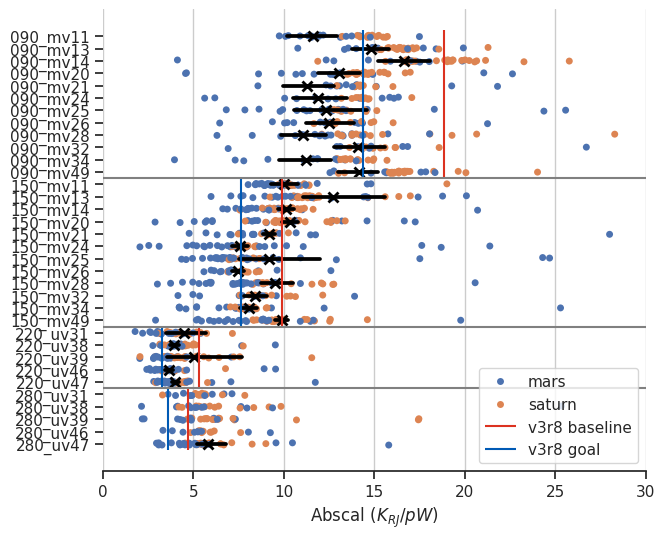

In [12]:
sns.set_theme(style="ticks")
t_cut = Time("2024-09-03T00:00:00", format="isot", scale="utc")


# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7, 6))
# ax.set_xscale("log")

# Load the example planets dataset
# planets = sns.load_dataset("planets")

# Plot the orbital period with horizontal boxes
# sns.boxplot(
#    planets, x="distance", y="method", hue="method",
#    whis=[0, 100], width=.6, palette="vlag"
# )

# Add in points to show each observation
sns.stripplot(
    old_df.where((old_df.pwvs < 3) & (old_df.cals < 50) & (old_df.times > t_cut.unix)),
    x="cals",
    y="labels",
    hue="sources",
    zorder=1,
)  # note somewhat nasty cut on cals since neptune keeps slipping into our saturn obs
sns.pointplot(
    data=df.where((old_df.pwvs < 3) & (old_df.cals < 50) & (old_df.times > t_cut.unix)),
    x="cals",
    y="labels",
    linestyle="none",
    marker="x",
    color="0.0",
    zorder=2,
)

ymax, ymin = ax.get_ylim()
xmax, xmin = ax.get_xlim()

pos_090 = (len([label for label in set(df[(df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)].labels.to_numpy()) if "090" in label]) - 0.5)
pos_150 = pos_090 + len([label for label in set(df[(df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)].labels.to_numpy()) if "150" in label])
pos_220 = pos_150 + len([label for label in set(df[(df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)].labels.to_numpy()) if "220" in label])
pos_280 = pos_220 + len([label for label in set(df[(df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)].labels.to_numpy()) if "280" in label])

plt.vlines(1.0 / (1e12 * (sim["MF"]["baseline"]["MF_1"]["dpdt_rj"])), ymin=ymin, ymax=pos_090, label="v3r8 baseline", color=c_base,)
plt.vlines(1.0 / (1e12 * (sim["MF"]["goal"]["MF_1"]["dpdt_rj"])), ymin=ymin, ymax=pos_090, label="v3r8 goal", color=c_goal,)

plt.vlines(1.0 / (1e12 * (sim["MF"]["baseline"]["MF_2"]["dpdt_rj"])), ymin=pos_090, ymax=pos_150, label=None, color=c_base,)
plt.vlines(1.0 / (1e12 * (sim["MF"]["goal"]["MF_2"]["dpdt_rj"])), ymin=pos_090, ymax=pos_150, label=None, color=c_goal,)

plt.vlines(1.0 / (1e12 * (sim["UHF"]["baseline"]["UHF_1"]["dpdt_rj"])), ymin=pos_150, ymax=pos_220, label=None, color=c_base,)
plt.vlines(1.0 / (1e12 * (sim["UHF"]["goal"]["UHF_1"]["dpdt_rj"])), ymin=pos_150, ymax=pos_220, label=None, color=c_goal,)

plt.vlines(1.0 / (1e12 * (sim["UHF"]["baseline"]["UHF_2"]["dpdt_rj"])), ymin=pos_220, ymax=ymax, label=None, color=c_base,)
plt.vlines(1.0 / (1e12 * (sim["UHF"]["goal"]["UHF_2"]["dpdt_rj"])), ymin=pos_220, ymax=ymax, label=None, color=c_goal,)

plt.hlines([pos_090, pos_150, pos_220], xmin=xmin, xmax=xmax, color="0.5")

plt.xlim(0, 30)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(xlabel="Abscal ($K_{RJ}/pW$)", ylabel="")
sns.despine(trim=True, left=True)

plt.legend()
# f.savefig("./plts/new_abscal/abscal.pdf", dpi=600, bbox_inches='tight')
# f.savefig("./plts/new_abscal/abscal.png", dpi=600, bbox_inches='tight')

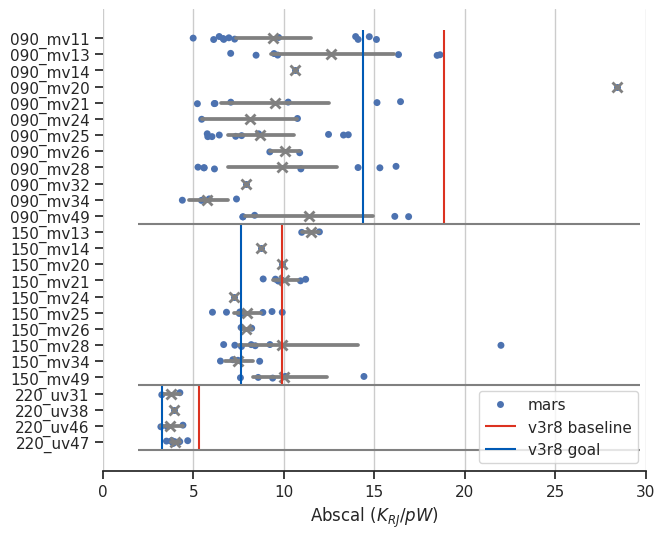

In [15]:
sns.set_theme(style="ticks")
t_cut = Time("2025-09-03T00:00:00", format="isot", scale="utc")


# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7, 6))
# ax.set_xscale("log")

# Load the example planets dataset
# planets = sns.load_dataset("planets")

# Plot the orbital period with horizontal boxes
# sns.boxplot(
#    planets, x="distance", y="method", hue="method",
#    whis=[0, 100], width=.6, palette="vlag"
# )

# Add in points to show each observation
sns.stripplot(
    df.where((df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)),
    x="cals",
    y="labels",
    hue="sources",
    zorder=1,
)  # note somewhat nasty cut on cals since neptune keeps slipping into our saturn obs
sns.pointplot(
    data=df.where((df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)),
    x="cals",
    y="labels",
    linestyle="none",
    marker="x",
    color="0.5",
    zorder=2,
)

ymax, ymin = ax.get_ylim()
xmax, xmin = ax.get_xlim()

pos_090 = (len([label for label in set(df[(df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)].labels.to_numpy()) if "090" in label]) - 0.5)
pos_150 = pos_090 + len([label for label in set(df[(df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)].labels.to_numpy()) if "150" in label])
pos_220 = pos_150 + len([label for label in set(df[(df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)].labels.to_numpy()) if "220" in label])
pos_280 = pos_220 + len([label for label in set(df[(df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)].labels.to_numpy()) if "280" in label])

plt.vlines(1.0 / (1e12 * (sim["MF"]["baseline"]["MF_1"]["dpdt_rj"])), ymin=ymin, ymax=pos_090, label="v3r8 baseline", color=c_base,)
plt.vlines(1.0 / (1e12 * (sim["MF"]["goal"]["MF_1"]["dpdt_rj"])), ymin=ymin, ymax=pos_090, label="v3r8 goal", color=c_goal,)

plt.vlines(1.0 / (1e12 * (sim["MF"]["baseline"]["MF_2"]["dpdt_rj"])), ymin=pos_090, ymax=pos_150, label=None, color=c_base,)
plt.vlines(1.0 / (1e12 * (sim["MF"]["goal"]["MF_2"]["dpdt_rj"])), ymin=pos_090, ymax=pos_150, label=None, color=c_goal,)

plt.vlines(1.0 / (1e12 * (sim["UHF"]["baseline"]["UHF_1"]["dpdt_rj"])), ymin=pos_150, ymax=pos_220, label=None, color=c_base,)
plt.vlines(1.0 / (1e12 * (sim["UHF"]["goal"]["UHF_1"]["dpdt_rj"])), ymin=pos_150, ymax=pos_220, label=None, color=c_goal,)

plt.vlines(1.0 / (1e12 * (sim["UHF"]["baseline"]["UHF_2"]["dpdt_rj"])), ymin=pos_220, ymax=ymax, label=None, color=c_base,)
plt.vlines(1.0 / (1e12 * (sim["UHF"]["goal"]["UHF_2"]["dpdt_rj"])), ymin=pos_220, ymax=ymax, label=None, color=c_goal,)

plt.hlines([pos_090, pos_150, pos_220], xmin=xmin, xmax=xmax, color="0.5")

plt.xlim(0, 30)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(xlabel="Abscal ($K_{RJ}/pW$)", ylabel="")
sns.despine(trim=True, left=True)

plt.legend()
# f.savefig("./plts/new_abscal/abscal.pdf", dpi=600, bbox_inches='tight')
# f.savefig("./plts/new_abscal/abscal.png", dpi=600, bbox_inches='tight')

# Results

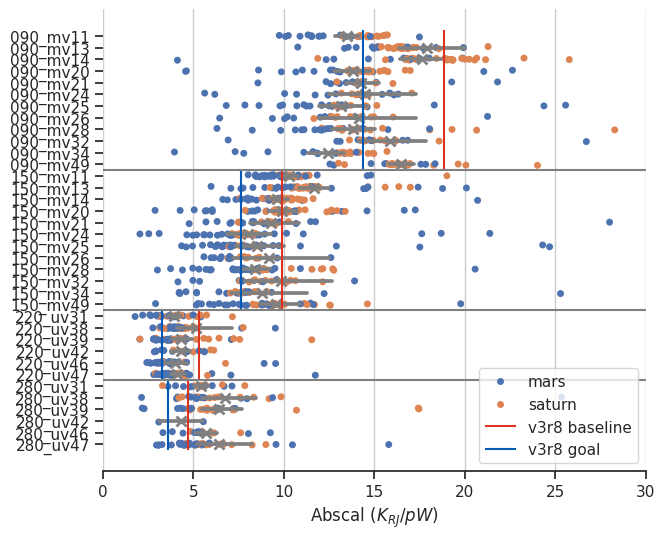

In [8]:
sns.set_theme(style="ticks")
t_cut = Time("2024-09-03T00:00:00", format="isot", scale="utc")


# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7, 6))
# ax.set_xscale("log")

# Load the example planets dataset
# planets = sns.load_dataset("planets")

# Plot the orbital period with horizontal boxes
# sns.boxplot(
#    planets, x="distance", y="method", hue="method",
#    whis=[0, 100], width=.6, palette="vlag"
# )

# Add in points to show each observation
sns.stripplot(
    df.where((df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)),
    x="cals",
    y="labels",
    hue="sources",
    zorder=1,
)  # note somewhat nasty cut on cals since neptune keeps slipping into our saturn obs
sns.pointplot(
    data=df.where((df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)),
    x="cals",
    y="labels",
    linestyle="none",
    marker="x",
    color="0.5",
    zorder=2,
)

ymax, ymin = ax.get_ylim()
xmax, xmin = ax.get_xlim()

pos_090 = (len([label for label in set(df[(df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)].labels.to_numpy()) if "090" in label]) - 0.5)
pos_150 = pos_090 + len([label for label in set(df[(df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)].labels.to_numpy()) if "150" in label])
pos_220 = pos_150 + len([label for label in set(df[(df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)].labels.to_numpy()) if "220" in label])
pos_280 = pos_220 + len([label for label in set(df[(df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)].labels.to_numpy()) if "280" in label])

plt.vlines(1.0 / (1e12 * (sim["MF"]["baseline"]["MF_1"]["dpdt_rj"])), ymin=ymin, ymax=pos_090, label="v3r8 baseline", color=c_base,)
plt.vlines(1.0 / (1e12 * (sim["MF"]["goal"]["MF_1"]["dpdt_rj"])), ymin=ymin, ymax=pos_090, label="v3r8 goal", color=c_goal,)

plt.vlines(1.0 / (1e12 * (sim["MF"]["baseline"]["MF_2"]["dpdt_rj"])), ymin=pos_090, ymax=pos_150, label=None, color=c_base,)
plt.vlines(1.0 / (1e12 * (sim["MF"]["goal"]["MF_2"]["dpdt_rj"])), ymin=pos_090, ymax=pos_150, label=None, color=c_goal,)

plt.vlines(1.0 / (1e12 * (sim["UHF"]["baseline"]["UHF_1"]["dpdt_rj"])), ymin=pos_150, ymax=pos_220, label=None, color=c_base,)
plt.vlines(1.0 / (1e12 * (sim["UHF"]["goal"]["UHF_1"]["dpdt_rj"])), ymin=pos_150, ymax=pos_220, label=None, color=c_goal,)

plt.vlines(1.0 / (1e12 * (sim["UHF"]["baseline"]["UHF_2"]["dpdt_rj"])), ymin=pos_220, ymax=ymax, label=None, color=c_base,)
plt.vlines(1.0 / (1e12 * (sim["UHF"]["goal"]["UHF_2"]["dpdt_rj"])), ymin=pos_220, ymax=ymax, label=None, color=c_goal,)
plt.hlines([pos_090, pos_150, pos_220], xmin=xmin, xmax=xmax, color="0.5")

plt.xlim(0, 30)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(xlabel="Abscal ($K_{RJ}/pW$)", ylabel="")
sns.despine(trim=True, left=True)

plt.legend()
# f.savefig("./plts/new_abscal/abscal.pdf", dpi=600, bbox_inches='tight')
# f.savefig("./plts/new_abscal/abscal.png", dpi=600, bbox_inches='tight')

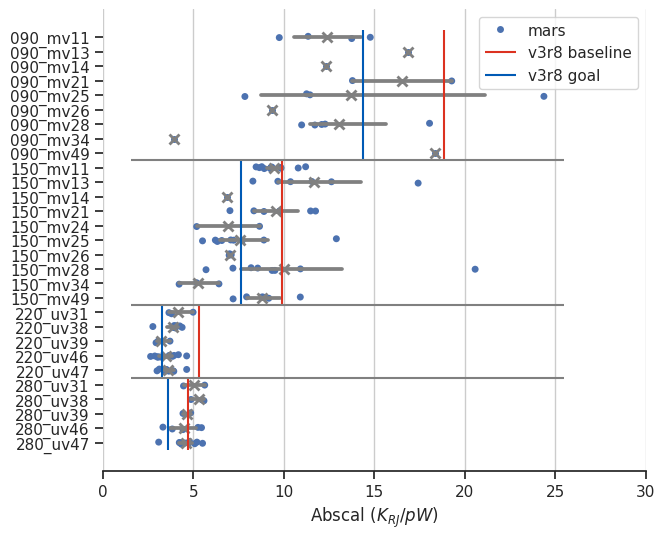

In [9]:
sns.set_theme(style="ticks")
t_cut = Time("2025-09-03T00:00:00", format="isot", scale="utc")


# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7, 6))
# ax.set_xscale("log")

# Load the example planets dataset
# planets = sns.load_dataset("planets")

# Plot the orbital period with horizontal boxes
# sns.boxplot(
#    planets, x="distance", y="method", hue="method",
#    whis=[0, 100], width=.6, palette="vlag"
# )

# Add in points to show each observation
sns.stripplot(
    df.where((df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)),
    x="cals",
    y="labels",
    hue="sources",
    zorder=1,
)  # note somewhat nasty cut on cals since neptune keeps slipping into our saturn obs
sns.pointplot(
    data=df.where((df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)),
    x="cals",
    y="labels",
    linestyle="none",
    marker="x",
    color="0.5",
    zorder=2,
)

ymax, ymin = ax.get_ylim()
xmax, xmin = ax.get_xlim()

pos_090 = (len([label for label in set(df[(df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)].labels.to_numpy()) if "090" in label]) - 0.5)
pos_150 = pos_090 + len([label for label in set(df[(df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)].labels.to_numpy()) if "150" in label])
pos_220 = pos_150 + len([label for label in set(df[(df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)].labels.to_numpy()) if "220" in label])
pos_280 = pos_220 + len([label for label in set(df[(df.pwvs < 3) & (df.cals < 50) & (df.times > t_cut.unix)].labels.to_numpy()) if "280" in label])

plt.vlines(1.0 / (1e12 * (sim["MF"]["baseline"]["MF_1"]["dpdt_rj"])), ymin=ymin, ymax=pos_090, label="v3r8 baseline", color=c_base,)
plt.vlines(1.0 / (1e12 * (sim["MF"]["goal"]["MF_1"]["dpdt_rj"])), ymin=ymin, ymax=pos_090, label="v3r8 goal", color=c_goal,)

plt.vlines(1.0 / (1e12 * (sim["MF"]["baseline"]["MF_2"]["dpdt_rj"])), ymin=pos_090, ymax=pos_150, label=None, color=c_base,)
plt.vlines(1.0 / (1e12 * (sim["MF"]["goal"]["MF_2"]["dpdt_rj"])), ymin=pos_090, ymax=pos_150, label=None, color=c_goal,)

plt.vlines(1.0 / (1e12 * (sim["UHF"]["baseline"]["UHF_1"]["dpdt_rj"])), ymin=pos_150, ymax=pos_220, label=None, color=c_base,)
plt.vlines(1.0 / (1e12 * (sim["UHF"]["goal"]["UHF_1"]["dpdt_rj"])), ymin=pos_150, ymax=pos_220, label=None, color=c_goal,)

plt.vlines(1.0 / (1e12 * (sim["UHF"]["baseline"]["UHF_2"]["dpdt_rj"])), ymin=pos_220, ymax=ymax, label=None, color=c_base,)
plt.vlines(1.0 / (1e12 * (sim["UHF"]["goal"]["UHF_2"]["dpdt_rj"])), ymin=pos_220, ymax=ymax, label=None, color=c_goal,)

plt.hlines([pos_090, pos_150, pos_220], xmin=xmin, xmax=xmax, color="0.5")

plt.xlim(0, 30)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(xlabel="Abscal ($K_{RJ}/pW$)", ylabel="")
sns.despine(trim=True, left=True)

plt.legend()
# f.savefig("./plts/new_abscal/abscal.pdf", dpi=600, bbox_inches='tight')
# f.savefig("./plts/new_abscal/abscal.png", dpi=600, bbox_inches='tight')

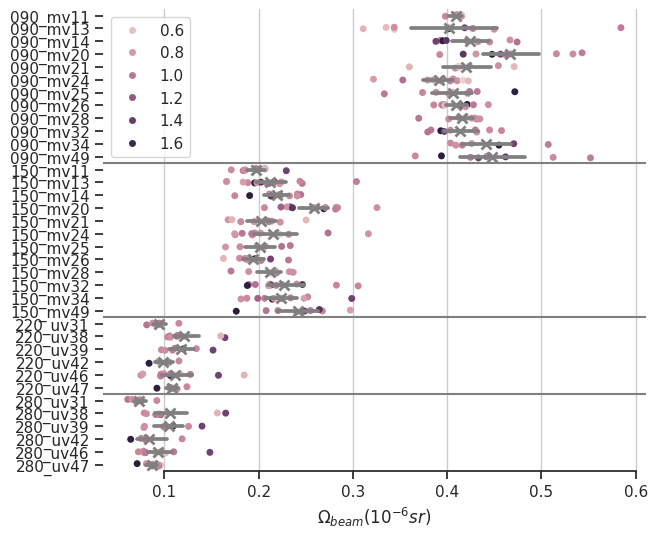

In [229]:
sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7, 6))
# ax.set_xscale("log")

ymax, ymin = ax.get_ylim()
xmax, xmin = ax.get_xlim()

pos_090 = len([label for label in set(df.labels.to_numpy()) if "090" in label]) - 0.5
pos_150 = pos_090 + len([label for label in set(df.labels.to_numpy()) if "150" in label])
pos_220 = pos_150 + len([label for label in set(df.labels.to_numpy()) if "220" in label])
pos_280 = pos_220 + len([label for label in set(df.labels.to_numpy()) if "280" in label])

plt.hlines([pos_090, pos_150, pos_220], xmin=xmin, xmax=xmax, color="0.5")
# Add in points to show each observation
sns.stripplot(df.where(df.pwvs < 2), x="omegas", y="labels", hue="pwvs", zorder=1)
sns.pointplot(
    data=df.where(df.pwvs < 2),
    x="omegas",
    y="labels",
    linestyle="none",
    marker="x",
    color="0.5",
    zorder=2,
)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(xlabel=r"$\Omega_{beam} (10^{-6} sr)$", ylabel="")
sns.despine(trim=True, left=True)

plt.legend()
f.savefig("./plts/abscal/omegas.pdf", dpi=600, bbox_inches="tight")
f.savefig("./plts/abscal/omegas.png", dpi=600, bbox_inches="tight")

# Optical Efficiencies

In [230]:
with open("abscals.pk", "rb") as f:
    abscal_dict = pk.load(f)

In [231]:
labels = []
raw_opt = []
cal_opt = []
obs = []
chis = []
pwvs = []

pwv = pwv_interp()

freqs = ["090", "150", "220", "280"]
ufms = sorted(result_dict.keys())

for (
    freq
) in freqs:  # This is slighly inefficient but the ezest way to sort by freq then ufm
    for ufm in ufms:
        for key in result_dict.keys():
            if ufm not in key:
                continue
            for sub_key in result_dict[key].keys():
                if freq not in sub_key:
                    continue
                cur_chis = np.array(result_dict[key][sub_key]["chi"])
                flags = np.where((25 <= cur_chis) & (cur_chis <= 1000))[0]
                cur_raw = np.array(result_dict[key][sub_key]["raw_opt"])[flags]
                cur_cal = np.array(result_dict[key][sub_key]["cal_opt"])[flags]
                cur_chis = cur_chis[flags]
                cur_obs = np.array(result_dict[key][sub_key]["obs"])[flags]

                label = str(freq) + "_" + str(ufm)
                for j in range(len(cur_raw)):
                    cur_pwv = pwv(cur_obs[j].split("_")[0])
                    raw_opt.append(cur_raw[j])
                    cal_opt.append(cur_cal[j])
                    chis.append(cur_chis[j])
                    labels.append(label)
                    obs.append(cur_obs[j])
                    pwvs.append(cur_pwv)


labels = np.array(labels)
raw_opt = np.array(raw_opt)
cal_opt = np.array(cal_opt)
chis = np.array(chis)
obs = np.array(obs)
pwvs = np.array(pwvs)

df = pd.DataFrame(
    {
        "labels": labels,
        "raw_opt": raw_opt,
        "cal_opt": cal_opt,
        "chis": chis,
        "obs": obs,
        "pwvs": pwvs,
    }
)

In [241]:
(
    (1e12 * sim["MF"]["baseline"]["MF_1"]["dpdt_rj"] * u.pW / u.K)
    / (consts.k_B * bandpasses["090"] * u.GHz)
).to(1)

<Quantity 0.13313026>

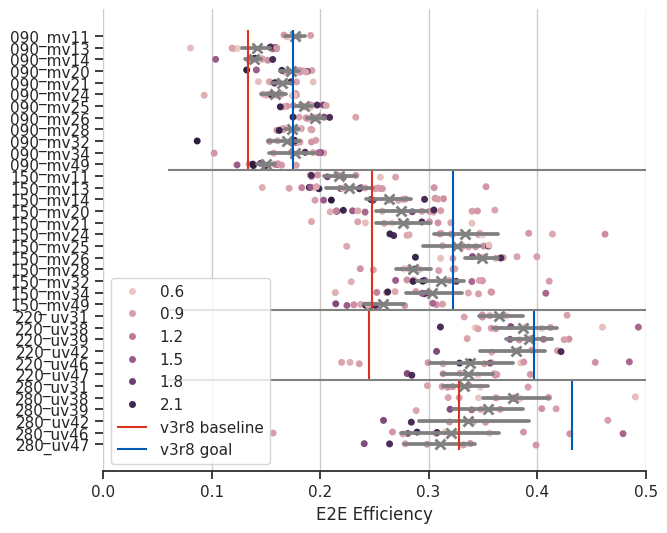

In [248]:
sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7, 6))


# Add in points to show each observation
sns.stripplot(
    df.where(df.raw_opt <= 0.5), x="raw_opt", y="labels", hue="pwvs", zorder=1
)
sns.pointplot(
    data=df.where(df.raw_opt <= 0.5),
    x="raw_opt",
    y="labels",
    linestyle="none",
    marker="x",
    color="0.5",
    zorder=2,
)

ymax, ymin = ax.get_ylim()
xmax, xmin = ax.get_xlim()

pos_090 = len([label for label in set(df.labels.to_numpy()) if "090" in label]) - 0.5
pos_150 = pos_090 + len(
    [label for label in set(df.labels.to_numpy()) if "150" in label]
)
pos_220 = pos_150 + len(
    [label for label in set(df.labels.to_numpy()) if "220" in label]
)
pos_280 = pos_220 + len(
    [label for label in set(df.labels.to_numpy()) if "280" in label]
)

# plt.vlines(0.125, ymin = ymin, ymax = pos_090, label="v3r8 baseline", color=c_base)
# plt.vlines(0.191, ymin = pos_090, ymax = pos_150, label=None, color=c_base)
# plt.vlines(0.236, ymin = pos_150, ymax = pos_220, label=None, color=c_base)
# plt.vlines(0.272, ymin = pos_220, ymax = ymax, label=None, color=c_base)


# (1e12*sim["MF"]["baseline"]["MF_1"]["dpdt_rj"]*u.pW/u.K)/(consts.k_B * bandpass * u.GHz).to(1)

plt.vlines(
    (
        (1e12 * sim["MF"]["baseline"]["MF_1"]["dpdt_rj"] * u.pW / u.K)
        / (consts.k_B * bandpasses["090"] * u.GHz)
    ).to(1),
    ymin=ymin,
    ymax=pos_090,
    label="v3r8 baseline",
    color=c_base,
)
plt.vlines(
    (
        (1e12 * sim["MF"]["goal"]["MF_1"]["dpdt_rj"] * u.pW / u.K)
        / (consts.k_B * bandpasses["090"] * u.GHz)
    ).to(1),
    ymin=ymin,
    ymax=pos_090,
    label="v3r8 goal",
    color=c_goal,
)

plt.vlines(
    (
        (1e12 * sim["MF"]["baseline"]["MF_2"]["dpdt_rj"] * u.pW / u.K)
        / (consts.k_B * bandpasses["150"] * u.GHz)
    ).to(1),
    ymin=pos_090,
    ymax=pos_150,
    label=None,
    color=c_base,
)
plt.vlines(
    (
        (1e12 * sim["MF"]["goal"]["MF_2"]["dpdt_rj"] * u.pW / u.K)
        / (consts.k_B * bandpasses["150"] * u.GHz)
    ).to(1),
    ymin=pos_090,
    ymax=pos_150,
    label=None,
    color=c_goal,
)

plt.vlines(
    (
        (1e12 * sim["UHF"]["baseline"]["UHF_1"]["dpdt_rj"] * u.pW / u.K)
        / (consts.k_B * bandpasses["220"] * u.GHz)
    ).to(1),
    ymin=pos_150,
    ymax=pos_220,
    label=None,
    color=c_base,
)
plt.vlines(
    (
        (1e12 * sim["UHF"]["goal"]["UHF_1"]["dpdt_rj"] * u.pW / u.K)
        / (consts.k_B * bandpasses["220"] * u.GHz)
    ).to(1),
    ymin=pos_150,
    ymax=pos_220,
    label=None,
    color=c_goal,
)

plt.vlines(
    (
        (1e12 * sim["UHF"]["baseline"]["UHF_2"]["dpdt_rj"] * u.pW / u.K)
        / (consts.k_B * bandpasses["280"] * u.GHz)
    ).to(1),
    ymin=pos_220,
    ymax=ymax,
    label=None,
    color=c_base,
)
plt.vlines(
    (
        (1e12 * sim["UHF"]["goal"]["UHF_2"]["dpdt_rj"] * u.pW / u.K)
        / (consts.k_B * bandpasses["280"] * u.GHz)
    ).to(1),
    ymin=pos_220,
    ymax=ymax,
    label=None,
    color=c_goal,
)


plt.hlines([pos_090, pos_150, pos_220], xmin=xmin, xmax=xmax, color="0.5")

plt.xlim(0, 0.5)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(xlabel="E2E Efficiency", ylabel="")
sns.despine(trim=True, left=True)

plt.legend()
f.savefig("./plts/e2e_eff.pdf", dpi=600, bbox_inches="tight")
f.savefig("./plts/e2e_eff.png", dpi=600, bbox_inches="tight")